In [221]:
##step 1: Importing libraries
import numpy as np
import pandas as pd

In [222]:
##step 2: Data Importing and Analysis
dataset = pd.read_csv("SMSSpamCollection", sep='\t',names=['label','message'],on_bad_lines='skip')

In [223]:
dataset

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [224]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [225]:
dataset.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [226]:
dataset['label'] = dataset['label'].map({'ham':0,'spam':1})

In [227]:
dataset

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [228]:
print(dataset.head())
print(dataset.isnull().sum())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
label      0
message    0
dtype: int64


In [229]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

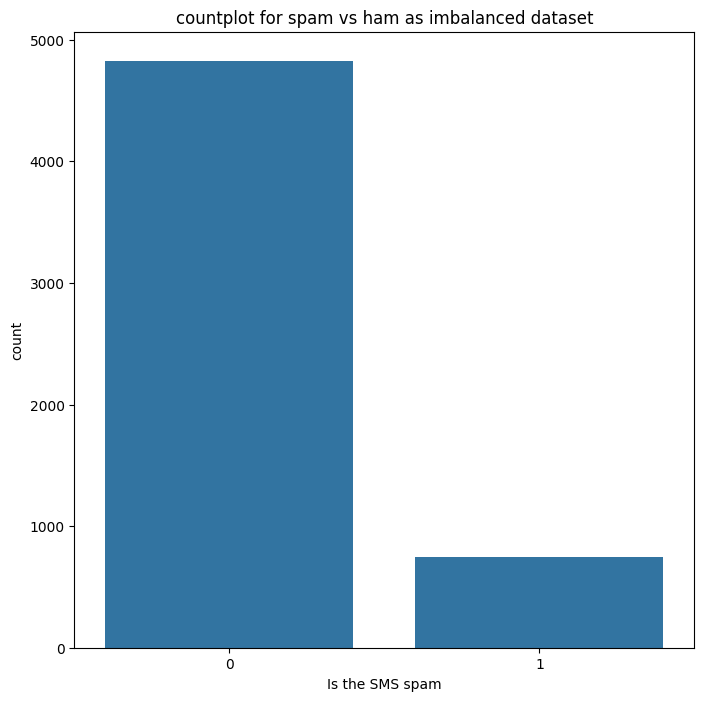

In [230]:
##countplot for spam vs ham as imbalanced dataset
plt.figure(figsize=(8,8))
g = sns.countplot(x="label",data=dataset)
p = plt.title('countplot for spam vs ham as imbalanced dataset')
p = plt.xlabel('Is the SMS spam')
p = plt.ylabel('count')
plt.show()

In [231]:
##Handling imbalanced dataset using oversampling
only_spam = dataset[dataset["label"] == 1]

In [232]:
only_spam

,label,message
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [233]:
only_ham = dataset[dataset['label'] == 0]

In [234]:
only_ham

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
6,0,Even my brother is not like to speak with me. ...
...,...,...
5565,0,Huh y lei...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [235]:
print('No of Spam SMS:', len(only_spam))
print('No of Ham SMS:', len(only_ham))

No of Spam SMS: 747
No of Ham SMS: 4825


In [236]:
count = int(only_ham.shape[0]/only_spam.shape[0])

In [237]:
count

6

In [238]:
for i in range(0,count-1):
       dataset = pd.concat([dataset,only_spam], ignore_index=True)
dataset.shape    

(9307, 2)

/tmp/ipykernel_17121/4222546717.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Ham', 'Spam'])


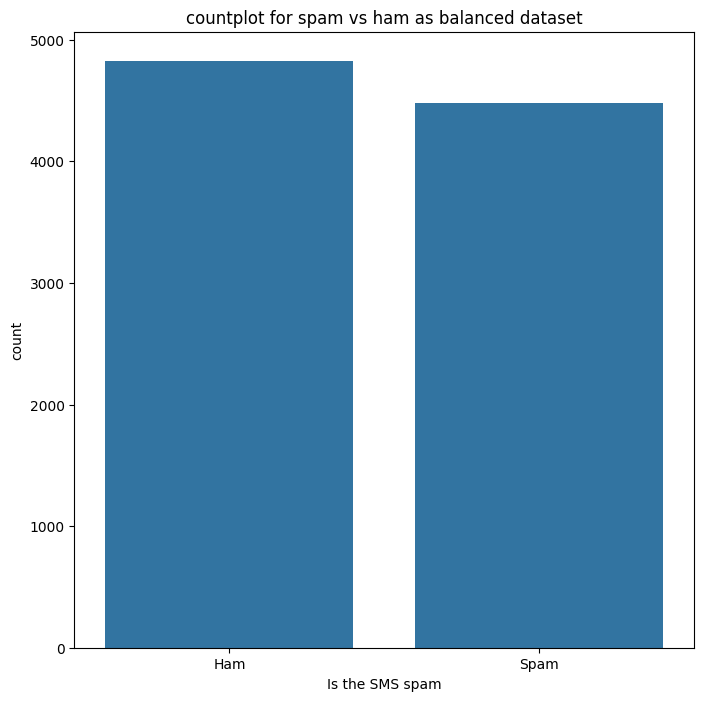

In [239]:
##countplot for balanced dataset
plt.figure(figsize=(8,8))
g = sns.countplot(x="label",data=dataset)
p = plt.title('countplot for spam vs ham as balanced dataset')
p = plt.xlabel('Is the SMS spam')
p = plt.ylabel('count')
g.set_xticklabels(['Ham', 'Spam'])
plt.show()

In [240]:
##Creating new feature word_count
dataset['word_count'] = dataset['message'].apply(lambda x:len(x.split()))
dataset

,label,message,word_count
0,0,"Go until jurong point, crazy.. Available only ...",20
1,0,Ok lar... Joking wif u oni...,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,0,U dun say so early hor... U c already then say...,11
4,0,"Nah I don't think he goes to usf, he lives aro...",13
...,...,...,...
9302,1,Want explicit SEX in 30 secs? Ring 02073162414...,16
9303,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33
9304,1,Had your contract mobile 11 Mnths? Latest Moto...,28
9305,1,REMINDER FROM O2: To get 2.50 pounds free call...,28


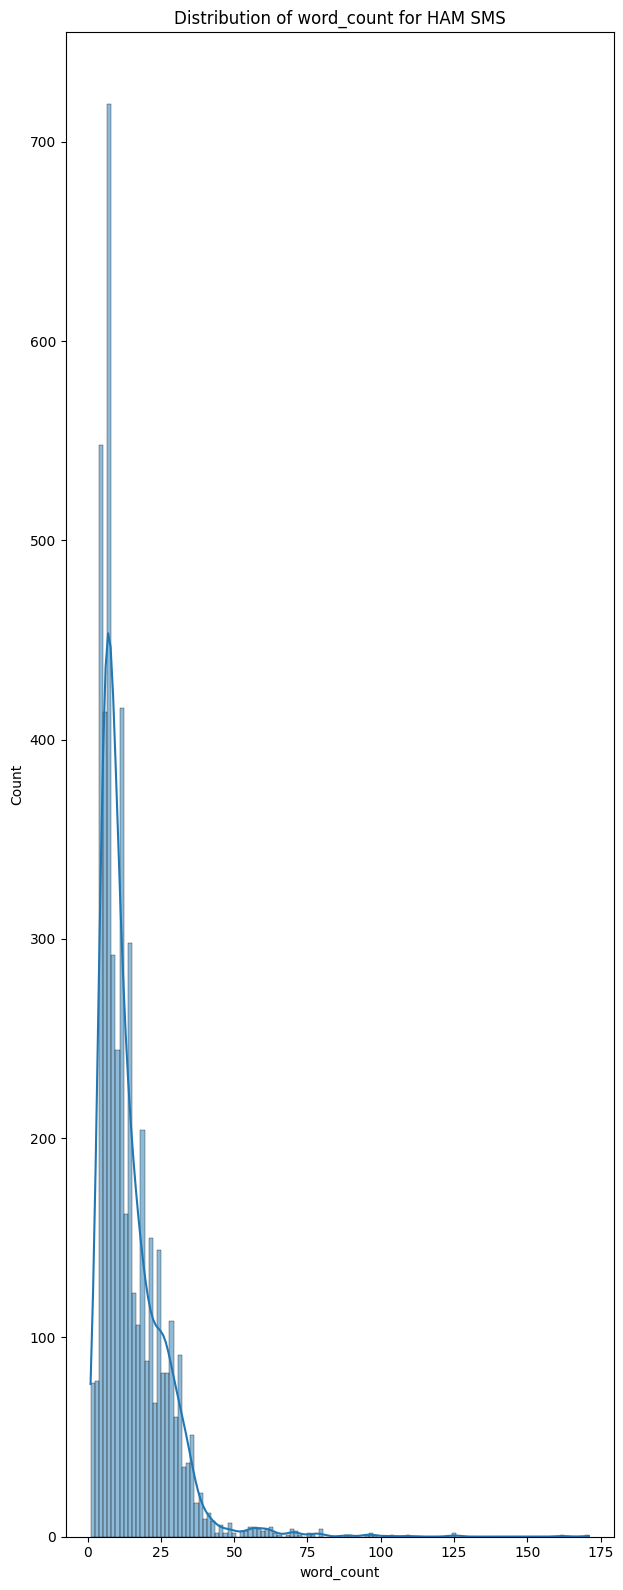

In [241]:
plt.figure(figsize=(12,16))
#(1,1)
plt.subplot(1,2,1)
g = sns.histplot(dataset[dataset["label"] == 0].word_count,kde=True)
p = plt.title('Distribution of word_count for HAM SMS')
plt.tight_layout()
plt.show()

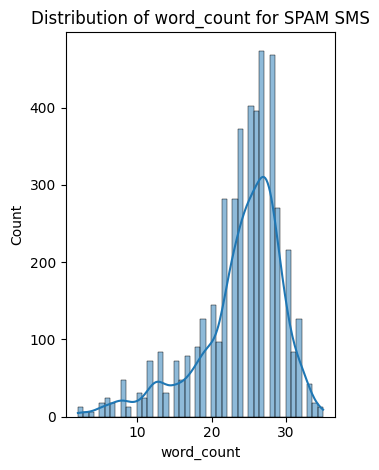

In [242]:
#(1,2)
plt.subplot(1,2,2)
g = sns.histplot(dataset[dataset["label"] == 1].word_count,kde = True)
p = plt.title('Distribution of word_count for SPAM SMS')
plt.tight_layout()
plt.show()

In [243]:
##Creating new feature of containing currency symbols
def currency(data):
    currency_symbols = ['€','$','¥','£','₹']
    for i in currency_symbols:
        if i in data:
            return 1
        return 0    

In [244]:
dataset["contains_currency_symbols"] = dataset["message"].apply(currency)

In [245]:
dataset

,label,message,word_count,contains_currency_symbols
0,0,"Go until jurong point, crazy.. Available only ...",20,0
1,0,Ok lar... Joking wif u oni...,6,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0
3,0,U dun say so early hor... U c already then say...,11,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0
...,...,...,...,...
9302,1,Want explicit SEX in 30 secs? Ring 02073162414...,16,0
9303,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,0
9304,1,Had your contract mobile 11 Mnths? Latest Moto...,28,0
9305,1,REMINDER FROM O2: To get 2.50 pounds free call...,28,0


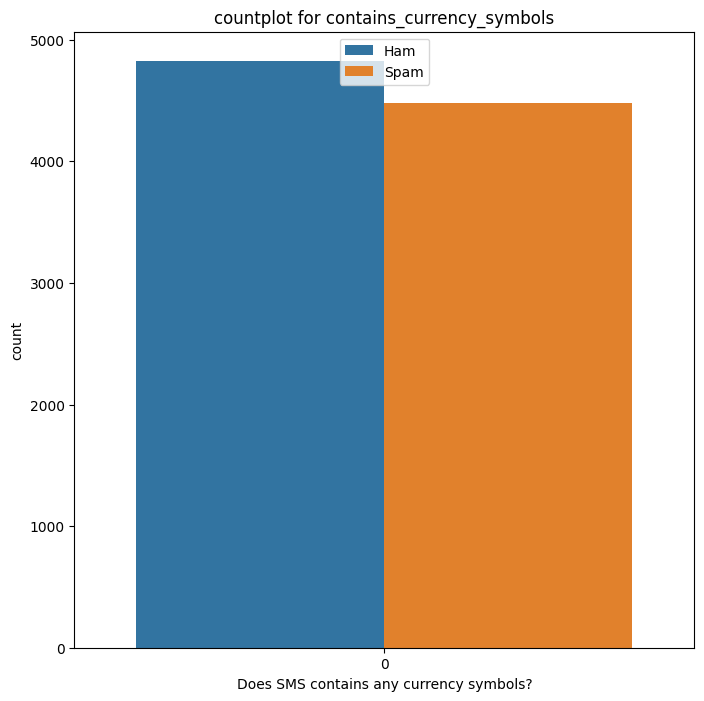

In [246]:
##countplot for conatins_currency_symbols
plt.figure(figsize=(8,8))
g = sns.countplot(x = 'contains_currency_symbols',data = dataset,hue = "label")
p = plt.title('countplot for contains_currency_symbols')
p = plt.xlabel("Does SMS contains any currency symbols?")
p = plt.ylabel("count")
p = plt.legend(labels = ["Ham","Spam"],loc = 9)
plt.show()

In [247]:
##Creating new feature of containing numbers
def number(data):
    for i in data:
        if ord(i) >= 48 and ord(i) <= 57:
            return 1
        return 0       

In [248]:
dataset["contains_number"] = dataset["message"].apply(number)

In [249]:
dataset

,label,message,word_count,contains_currency_symbols,contains_number
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,0
3,0,U dun say so early hor... U c already then say...,11,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0
...,...,...,...,...,...
9302,1,Want explicit SEX in 30 secs? Ring 02073162414...,16,0,0
9303,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,0,0
9304,1,Had your contract mobile 11 Mnths? Latest Moto...,28,0,0
9305,1,REMINDER FROM O2: To get 2.50 pounds free call...,28,0,0


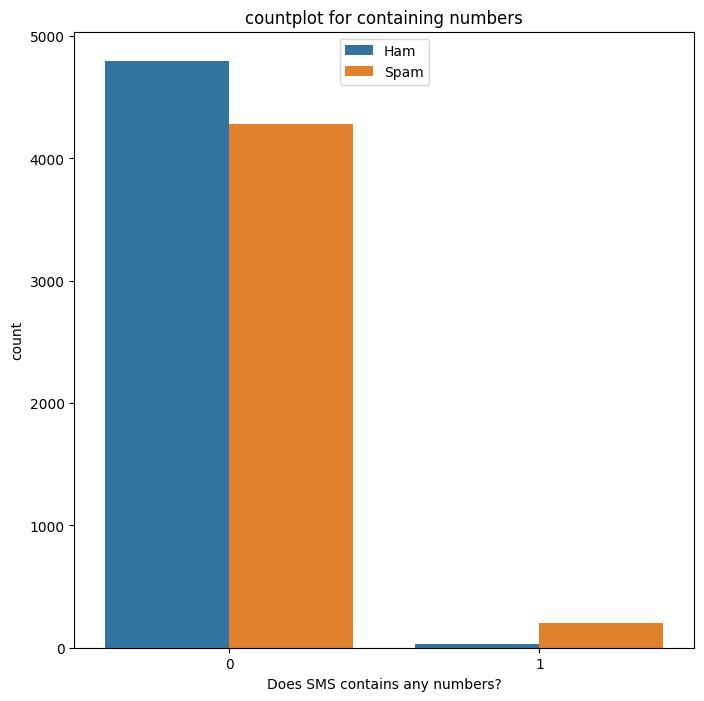

In [250]:
##countplot for conatinging numbers
plt.figure(figsize=(8,8))
g = sns.countplot(x = 'contains_number',data = dataset,hue = "label")
p = plt.title('countplot for containing numbers')
p = plt.xlabel("Does SMS contains any numbers?")
p = plt.ylabel("count")
p = plt.legend(labels = ["Ham","Spam"],loc = 9)
plt.show()

In [251]:
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /home/vani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vani/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [252]:
corpus = []
wnl = WordNetLemmatizer()
for sms in list(dataset.message):
    message = re.sub(pattern =r'[^a-zA-Z\s]', repl = '', string = sms)
    message = message.lower()
    words = message.split()

In [253]:
filteredwords = [word for word in words if word not in set(stopwords.words('english'))]

In [254]:
lemm_words = [wnl.lemmatize(word) for word in message.split()]
message = ' '.join(lemm_words)
corpus.append(message)

In [255]:
corpus

['this is the nd time we have tried contact u u have won the pound prize claim is easy call now only p per minute btnationalrate']

In [256]:
print(len(corpus))

1


## Creating the bag of words model

In [257]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 500)
vectors = tfidf.fit_transform(corpus).toarray()
feature_names = tfidf.get_feature_names_out()

In [258]:
feature_names

array(['btnationalrate', 'call', 'claim', 'contact', 'easy', 'have', 'is',
       'minute', 'nd', 'now', 'only', 'per', 'pound', 'prize', 'the',
       'this', 'time', 'tried', 'we', 'won'], dtype=object)

In [259]:
X = pd.DataFrame(vectors, columns = feature_names)
y = dataset['label']

In [260]:
print(X.shape)
print(y.shape)

(1, 20)
(9307,)


In [261]:
X = dataset.drop('label', axis=1)  # drop the label column, keep all rows
y = dataset['label']               # just the label column

# Check shapes again
print(X.shape)  # should be (9310, n_features)
print(y.shape)  # should be (9310,)


(9307, 4)
(9307,)


In [262]:
#from sklearn.naive_bayes import MultinomialNB
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [263]:
X_train

,message,word_count,contains_currency_symbols,contains_number
3533,"Actually, my mobile is full of msg. And i m do...",28,0,0
2592,Still work going on:)it is very small house.,8,0,0
4253,"Send ur birthdate with month and year, I will ...",22,0,0
6976,Want the latest Video handset? 750 anytime any...,21,0,0
7191,"Dear Voucher Holder, To claim this weeks offer...",24,0,0
...,...,...,...,...
5734,URGENT! We are trying to contact U. Todays dra...,27,0,0
5191,"Sorry, I'll call later",4,0,0
5390,Nt joking seriously i told,5,0,0
860,Did he just say somebody is named tampa,8,0,0


In [264]:
X_test

,message,word_count,contains_currency_symbols,contains_number
1155,Did u find a sitter for kaitlyn? I was sick an...,15,0,0
1790,Takin a shower now but yeah I'll leave when I'...,11,0,0
3003,"Excellent, I'll see what riley's plans are",7,0,0
6489,Do you want 750 anytime any network mins 150 t...,29,0,0
592,You have been specially selected to receive a ...,24,0,0
...,...,...,...,...
4147,I cant wait for cornwall. Hope tonight isnt ...,32,0,0
274,"Usf I guess, might as well take 1 car",9,0,0
1345,Were somewhere on Fredericksburg,4,0,0
8891,Tone Club: Your subs has now expired 2 re-sub ...,32,0,0


## NAIVE BAYES Model

In [265]:
X = dataset['message']         
y = dataset['label']

In [266]:
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
9302    Want explicit SEX in 30 secs? Ring 02073162414...
9303    ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
9304    Had your contract mobile 11 Mnths? Latest Moto...
9305    REMINDER FROM O2: To get 2.50 pounds free call...
9306    This is the 2nd time we have tried 2 contact u...
Name: message, Length: 9307, dtype: object

In [267]:
y

0       0
1       0
2       1
3       0
4       0
       ..
9302    1
9303    1
9304    1
9305    1
9306    1
Name: label, Length: 9307, dtype: int64

In [268]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

# Convert raw text (X) into a matrix of token counts
vectorizer = CountVectorizer()
X_vect = vectorizer.fit_transform(X)  # X must be a 1D array/Series of text

# Then fit your model
model = MultinomialNB()
cv_scores = cross_val_score(model, X_vect, y, scoring='f1_macro', cv=10)

print("Mean F1 (macro):", round(cv_scores.mean(), 4))
print("Std Dev:", round(cv_scores.std(), 4))


Mean F1 (macro): 0.9859
Std Dev: 0.0029


In [269]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# Assuming df is already loaded and preprocessed
X = dataset['message']  # text data
y = dataset['label']    # target labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization: convert text to numerical features
vectorizer = CountVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Initialize the Naive Bayes model
mnb = MultinomialNB()

# Train the model
mnb.fit(X_train_vect, y_train)

# Make predictions
y_pred = mnb.predict(X_test_vect)

# Output classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Output confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       959
           1       0.99      0.98      0.99       903

    accuracy                           0.99      1862
   macro avg       0.99      0.99      0.99      1862
weighted avg       0.99      0.99      0.99      1862

Confusion Matrix:


In [270]:
cm

array([[954,   5],
       [ 15, 888]])

In [271]:
print(cm.shape)

(2, 2)


Confusion Matrix Shape: (2, 2)


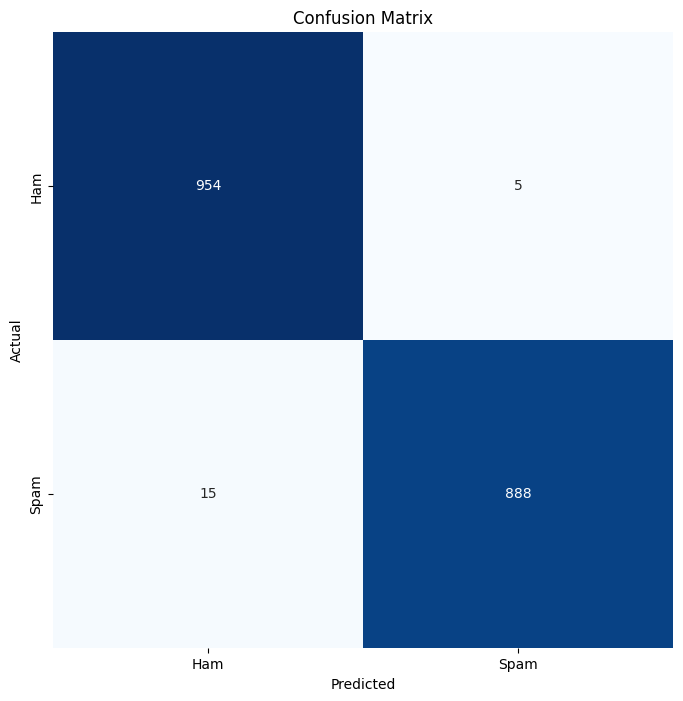

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Shape:", cm.shape)

axis_labels = ['Ham', 'Spam']
plt.figure(figsize=(8, 8))
sns.heatmap(data=cm, xticklabels=axis_labels, yticklabels=axis_labels, annot=True, fmt='g', cbar=False, cmap="Blues")

# Display the plot
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [273]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier

X = dataset['message']  
y = dataset['label']    

vectorizer = CountVectorizer()
X_vect = vectorizer.fit_transform(X)
dt = DecisionTreeClassifier()

cv1 = cross_val_score(dt, X_vect, y, scoring='f1_macro', cv=10)

print("Mean F1 (macro):", round(cv1.mean(), 3))
print("Std Dev:", round(cv1.std(), 3))


Mean F1 (macro): 0.988
Std Dev: 0.005


In [274]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X = dataset['message']  
y = dataset['label']    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data
vectorizer = CountVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)  
X_test_vect = vectorizer.transform(X_test)

dt = DecisionTreeClassifier()

dt.fit(X_train_vect, y_train)
y_pred = dt.predict(X_test_vect)

# Print the classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99       959
           1       0.97      1.00      0.99       903

    accuracy                           0.99      1862
   macro avg       0.99      0.99      0.99      1862
weighted avg       0.99      0.99      0.99      1862



In [275]:
cm = confusion_matrix(y_test,y_pred)

In [276]:
cm

array([[934,  25],
       [  0, 903]])

Confusion Matrix Shape: (2, 2)


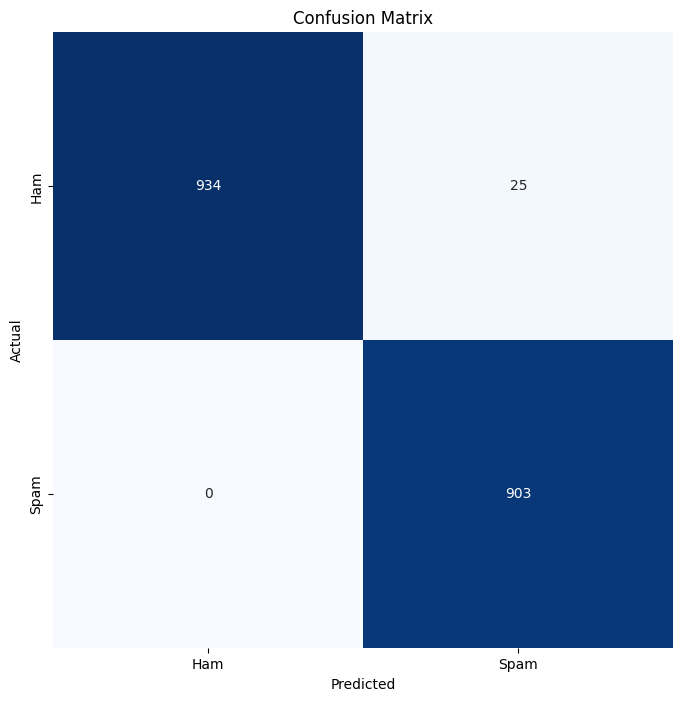

In [277]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Shape:", cm.shape)

axis_labels = ['Ham', 'Spam']
plt.figure(figsize=(8, 8))
sns.heatmap(data=cm, xticklabels=axis_labels, yticklabels=axis_labels, annot=True, fmt='g', cbar=False, cmap="Blues")

# Display the plot
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [283]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# Split your data
X_train, X_test, y_train, y_test = train_test_split(dataset['message'], dataset['label'], test_size=0.2, random_state=42)

# Train your TF-IDF vectorizer on training data only
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train the model
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)


MultinomialNB()

In [284]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
wnl = WordNetLemmatizer()

def predict_spam(sms):
    message = re.sub(r'[^a-zA-Z\s]', '', sms)
    message = message.lower()
    words = message.split()
    filtered_words = [word for word in words if word not in stop_words]
    lemm_words = [wnl.lemmatize(word) for word in filtered_words]
    final_message = ' '.join(lemm_words)
    temp = tfidf.transform([final_message]).toarray()
    return mnb.predict(temp)[0]


## Prediction1 - Lottery text message

In [285]:
sample_message = 'Important - you could be entitled up to £3,160 in compensation from mis_sold PPI on a credit card or loan'
if predict_spam(sample_message) == 'spam':
    print("Gotcha! This is a SPAM message")
else:
    print("This is a HAM message")

This is a HAM message
